Loading and Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# Drop the unnecessary 'Unnamed: 0' column
df = df.drop(columns=['Unnamed: 0'])

# Convert date to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print(f"Dataset loaded with {df.shape[0]} rows.")
df.head()

Dataset loaded with 1407328 rows.


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Headline Length

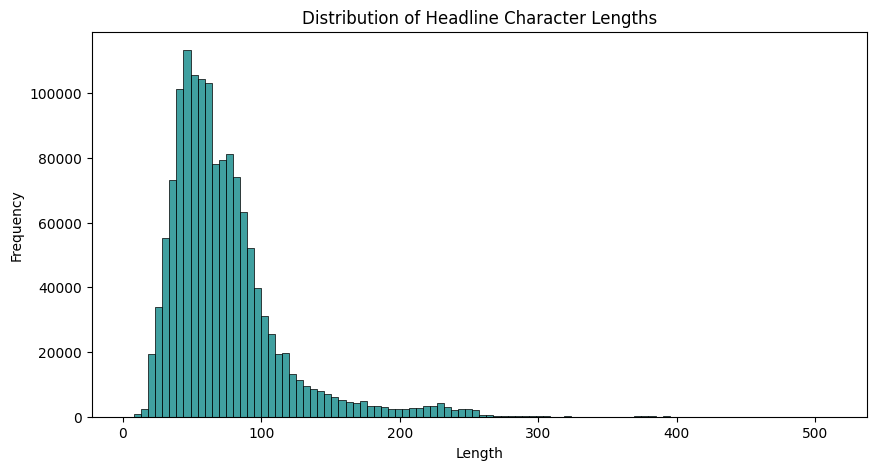

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


In [2]:
df['headline_len'] = df['headline'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df['headline_len'], bins=100, color='teal')
plt.title('Distribution of Headline Character Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

print(df['headline_len'].describe())

Publisher Analysis
 
 (Identify the top 10 publishers)

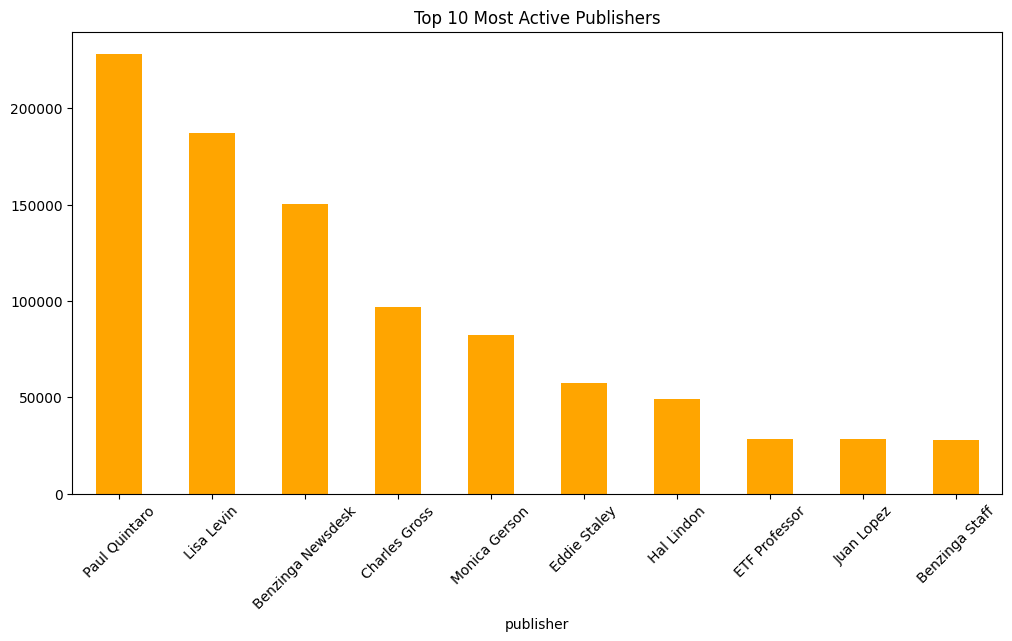

In [3]:

top_publishers = df['publisher'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_publishers.plot(kind='bar', color='orange')
plt.title('Top 10 Most Active Publishers')
plt.xticks(rotation=45)
plt.show()

Analyzing News Volume Over Time

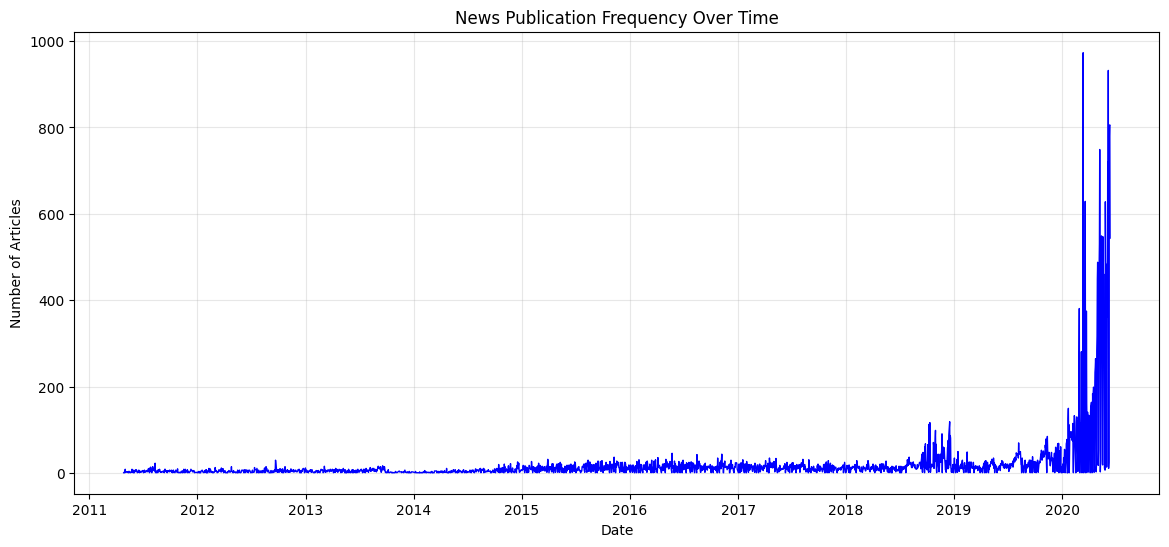

The highest news volume was on: 2020-03-12 with 973 articles.


In [4]:
# 1. Count articles per day
daily_news_counts = df['date'].dt.date.value_counts().sort_index()

# 2. Plotting the Time Series
plt.figure(figsize=(14, 6))
daily_news_counts.plot(kind='line', color='blue', linewidth=1)
plt.title('News Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Find the day with the most news (the "Spike")
peak_day = daily_news_counts.idxmax()
print(f"The highest news volume was on: {peak_day} with {daily_news_counts.max()} articles.")

Analyzing Publication Times (The "Hour" effect)

/tmp/ipykernel_78721/1323159081.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='viridis')


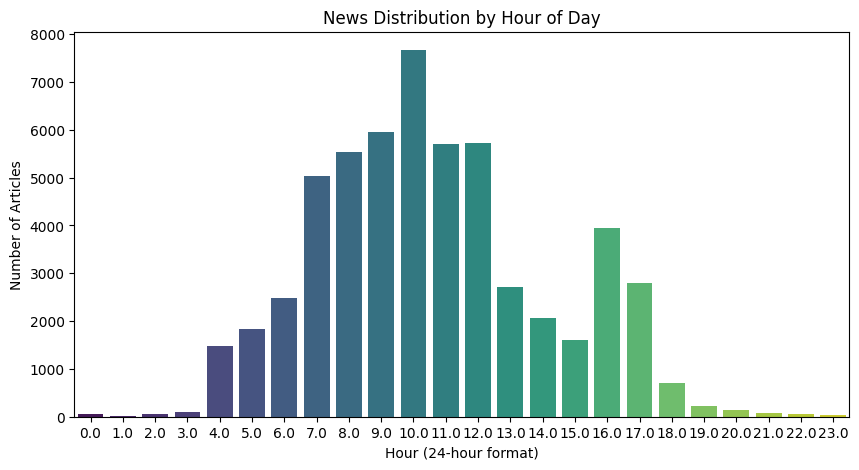

In [5]:
# Extract the hour from the date
df['hour'] = df['date'].dt.hour

plt.figure(figsize=(10, 5))
sns.countplot(x='hour', data=df, palette='viridis')
plt.title('News Distribution by Hour of Day')
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Number of Articles')
plt.show()

 1. Initialize the vectorizer to find common phrases (2-3 words long)
 We remove 'english' stop words (like 'the', 'is', 'at') to get meaningful data
 2. Extract words and their frequencies
 3. Convert to DataFrame for easy plotting
 4. Plot the results

/tmp/ipykernel_78721/1575436939.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Phrase', data=words_df, palette='Reds_r')


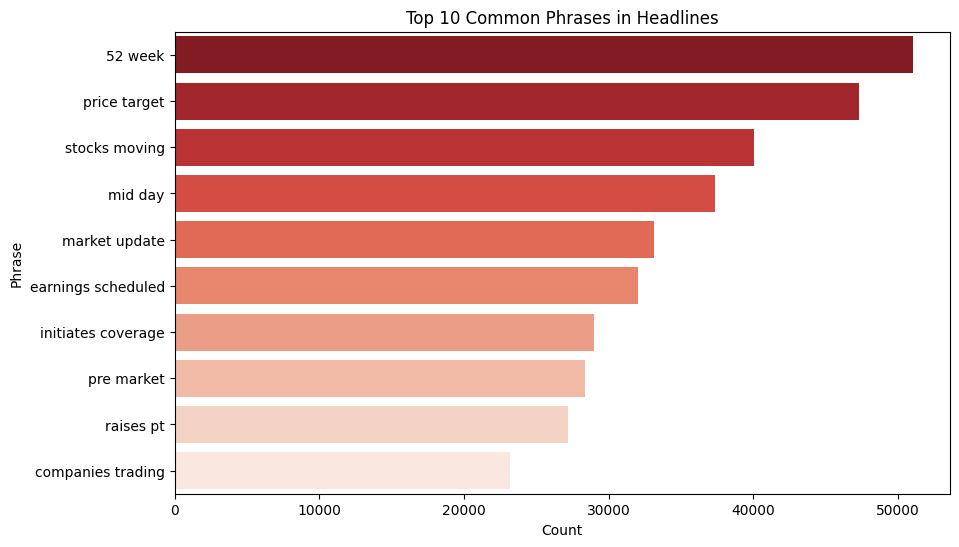

In [6]:
from sklearn.feature_extraction.text import CountVectorizer


vec = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
bag_of_words = vec.fit_transform(df['headline'].dropna())
sum_words = bag_of_words.sum(axis=0)


words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)


words_df = pd.DataFrame(words_freq, columns=['Phrase', 'Count'])


plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Phrase', data=words_df, palette='Reds_r')
plt.title('Top 10 Common Phrases in Headlines')
plt.show()

Publisher Domain Extraction (Final Cleanup)

In [7]:
# Extract the domain if the publisher is an email
df['publisher_clean'] = df['publisher'].str.extract(r'@([\w\.-]+)')
df['publisher_clean'] = df['publisher_clean'].fillna(df['publisher'])

# Show the cleaned top publishers
print("Top Cleaned Publishers:")
print(df['publisher_clean'].value_counts().head(10))

Top Cleaned Publishers:
publisher_clean
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64
